You can find the lecture [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/lectures/L04_probability.ipynb)

In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
z= np.loadtxt('dr7qso.dat',skiprows=80, usecols=3)

Histogram for _rejection sampling_

In [70]:
hist, bin_edges = np.histogram(z,density=True)

Histogram for _inverse function sampling_

In [74]:
#new histogram since more bins are necessary for a smooth cdf
hist_ifs, bin_edges_ifs = np.histogram(z,bins=10**2)

## Cloning with rejection sampling

- pick a uniform distribution $q(z)$ over `np.min(z)` and `np.max(z)`
- draw a random $z_i$ in the region 
- draw a random number $u$ from the uniform distribution over $[0,\max(h(x)]$
- if $u<h(z_i)$, accept the point or else reject.

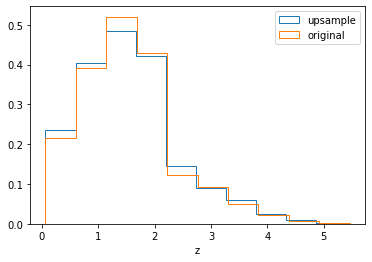

In [79]:
N=10**4 #overall draws
zi=np.random.uniform(np.min(z),np.max(z),N)
#------------------------
ui=np.random.uniform(0,max(hist),N)
#------------------------
# assign zi to one bin i, then hi=hist[i]
bin_i=np.searchsorted(bin_edges,zi,side='right')-1
hi=hist[bin_i]
#------------------------
accepted_zi=zi[ui<hi]
#------------------------
plt.hist(accepted_zi,histtype='step',density=True,label='upsample');
plt.hist(z,histtype='step',density=True,label='original');
plt.legend()
plt.xlabel('z')
plt.show()

## Cloning with inverse function sampling
- Reconstruct the cdf $h(z)$ (`cdf`) of the original distribution $p(z)$;
- derive the inverse $[h(z)]^{-1}$ (`cdf_inv`);
- generate a random sample $u$ (`ui_ifs`) from a uniform distribution over $[0,1]$;
- `zi_ifs` such that $h^{-1}(u)=z$ is a cloned sample from the original distribution.

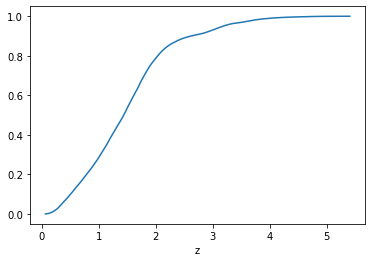

In [77]:
#reconstruct cdf h(z)
cdf=np.cumsum(hist_ifs)/np.sum(hist_ifs)
plt.plot(np.delete(bin_edges_ifs,len(bin_edges_ifs)-1),cdf);
plt.xlabel('z')
plt.show()

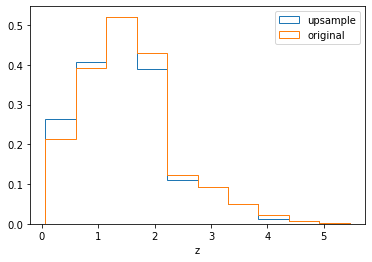

In [78]:
ui_ifs=np.random.uniform(0,1,N)
#------------------------
#indices of bins in which the preimages of the 'ui_ifs' fall
bin_i_inv=np.searchsorted(cdf,ui_ifs,side='right')-1
#the zi_ifs forming the upsample are the 'zi' at the indices specified above
zi_ifs=bin_edges_ifs[bin_i_inv]
#------------------------
plt.hist(zi_ifs,histtype='step',density=True,label='upsample');
plt.hist(z,histtype='step',density=True,label='original');
plt.legend()
plt.xlabel('z')
plt.show()